# ⚠️ Note importante avant exécution

> **Ce notebook peut prendre entre 20 et 40 minutes à s'exécuter complètement, selon les performances de la machine.**

Ce notebook travaille sur le dataset Kaggle **"Genius Song Lyrics with Language Information"**,
qui contient **plus de 5 millions de chansons** toutes langues confondues.
Le chargement seul (`pd.read_csv`) prend plusieurs minutes sur un ordinateur portable standard.

La durée d'exécution observée lors du développement :
- **PC fixe avec bonnes performances (32 GO de RAM)** : ~3–5 minutes
- **Ordinateur portable standard** : ~20 - 40 minutes

### Ce que fait ce notebook

C'est le **premier notebook** d'un pipeline en deux étapes :

| Notebook | Rôle | Données |
|---|---|---|
| **`data_prep_kpop_lyrics.ipynb`** (ce notebook) | Filtrage et nettoyage | 5 M chansons → ~30 K chansons K-pop |
| `data_analysis_kpop_lyrics.ipynb` | Analyse linguistique | ~30 K chansons |

**Le résultat de ce notebook** est un fichier `kpop_dataset_clean.csv` (~30 000 chansons)
que le second notebook charge directement - plus besoin de retoucher aux 5 millions de lignes.

>  *Pour reproduire l'analyse sans attendre, vous pouvez partir directement
> du fichier `kpop_dataset_clean.csv` fourni avec le dépôt GitHub et ouvrir le second notebook.*

---
# Préparation du dataset K-pop

## Source des données

Le dataset utilisé est **"Genius Song Lyrics with Language Information"** (Kaggle, `carlosgdcj`),
qui contient les paroles de plus de 5 millions de chansons issues de la plateforme Genius,
accompagnées d'une détection automatique de la langue via deux outils :
- **cld3** (Compact Language Detector 3, Google)
- **fastText** (Meta AI)

Les colonnes utilisées sont : `title`, `artist`, `year`, `lyrics`, `language_cld3`, `language_ft`, `language`.

## Démarche de filtrage

Pour isoler les artistes K-pop, on applique la logique suivante :

1. **Identifier les artistes coréens** : un artiste est retenu s'il a publié au moins **13 chansons
   détectées comme coréennes** (par au moins un des deux détecteurs de langue).
   Ce seuil, arbitraire, élimine les faux positifs (artistes non K-pop ayant quelques chansons en coréen par hasard).

2. **Garder toutes leurs chansons** : une fois un artiste identifié comme K-pop,
   on conserve **toutes** ses chansons, y compris celles entièrement en anglais
   (ex. *Dynamite* de BTS). C'est essentiel pour mesurer le code-switching.

3. **Supprimer les entrées parasites** : `"Genius Translations"` et `"Various Artists"`
   ne sont pas de vrais artistes K-pop et sont retirés.

## Fenêtre temporelle

L'étude couvre la période **2000 - 2022**, conformément aux recommandations de Mme Mathilde Hutin.
Un diagnostic préalable sur les données avant 2000 a montré des volumes trop faibles
pour une analyse statistique robuste.

## 1. Imports

In [2]:
import re
import kagglehub          # téléchargement automatique depuis Kaggle
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os

C:\Users\mrgne\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Chargement du dataset Kaggle

> ⏳ **Étape longue.** Le téléchargement initial depuis Kaggle puis le chargement CSV
> peuvent prendre **5 à 40 minutes** selon la connexion et la machine.
> Les exécutions suivantes seront plus rapides grâce au cache local de `kagglehub`.

In [3]:
# Téléchargement depuis Kaggle (mis en cache automatiquement après la première fois)
path = kagglehub.dataset_download("carlosgdcj/genius-song-lyrics-with-language-information")
print("Dataset téléchargé dans :", path)

Dataset téléchargé dans : C:\Users\mrgne\.cache\kagglehub\datasets\carlosgdcj\genius-song-lyrics-with-language-information\versions\1


In [5]:
df = pd.read_csv('song_lyrics.csv')
df

,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
0,Killa Cam,rap,Cam'ron,2004,173166,"{""Cam\\'ron"",""Opera Steve""}","[Chorus: Opera Steve & Cam'ron]\nKilla Cam, Ki...",1,en,en,en
1,Can I Live,rap,JAY-Z,1996,468624,{},"[Produced by Irv Gotti]\n\n[Intro]\nYeah, hah,...",3,en,en,en
2,Forgive Me Father,rap,Fabolous,2003,4743,{},Maybe cause I'm eatin\nAnd these bastards fien...,4,en,en,en
3,Down and Out,rap,Cam'ron,2004,144404,"{""Cam\\'ron"",""Kanye West"",""Syleena Johnson""}",[Produced by Kanye West and Brian Miller]\n\n[...,5,en,en,en
4,Fly In,rap,Lil Wayne,2005,78271,{},"[Intro]\nSo they ask me\n""Young boy\nWhat you ...",6,en,en,en
...,...,...,...,...,...,...,...,...,...,...,...
5134851,Ocean,pop,Effemar,2022,3,{},[Verse 1]\nDance for me now\nKeeping yourself ...,7882842,en,en,en
5134852,64 Bars,rap,Rapido,2022,4,{},"[Intro]\n\nJa, ja\n\n[Part 1]\n\nR-A-H, Merhab...",7882843,de,de,de
5134853,Raise Our Hands,pop,"Culture Code, Pag & Mylo",2016,3,"{Elex,""Culture Code / Pag & Mylo""}",[Verse 1]\nHere our purpose feels alive\nWe ar...,7882845,en,en,en
5134854,CEO,rap,Antropolita,2022,5,{},Jestem CEO w tym\nTo jara twoją bitch\nNikt na...,7882846,pl,pl,pl


## 3. Construction du dataset K-pop

### Stratégie de détection des artistes coréens

Le dataset Genius ne contient pas de tag « K-pop » explicite.
On identifie les artistes K-pop indirectement, via la **langue de leurs chansons** :
un artiste est retenu s'il a publié au moins **13 chansons détectées comme coréennes**
par au moins un des deux détecteurs (`cld3` ou `fastText`).

Ce seuil de 13 choisi arbitrairement est un compromis :
- Trop bas → on inclut des artistes non K-pop ayant quelques reprises ou collaborations en coréen
- Trop haut → on exclut des artistes K-pop légitimes mais peu représentés sur Genius

Une fois les artistes identifiés, on conserve **toutes** leurs chansons
(y compris les chansons entièrement en anglais), car ces chansons font partie
de la stratégie de code-switching que nous étudions.

### 3.1 Détecter les chansons en coréen

In [6]:
# Une chanson est coréenne si AU MOINS UN des trois détecteurs dit 'ko'.
# On utilise le OU logique pour maximiser le rappel (éviter les faux négatifs).
is_korean = (
    (df["language_cld3"].astype(str).str.strip().str.lower() == "ko") |
    (df["language_ft"].astype(str).str.strip().str.lower()   == "ko") |
    (df["language"].astype(str).str.strip().str.lower()      == "ko")
)

### 3.2 Compter les chansons coréennes par artistes

In [7]:
MIN_KOREAN_SONGS = 13   # seuil de qualification K-pop

korean_counts = df[is_korean]["artist"].value_counts()
kpop_artists  = korean_counts[korean_counts >= MIN_KOREAN_SONGS].index.tolist()

print(f"Artistes avec ≥ {MIN_KOREAN_SONGS} chansons coréennes : {len(kpop_artists):,}")

Artistes avec ≥ 13 chansons coréennes : 731


### 3.3 Garder toutes les chansons de ces artistes

In [8]:
df_kpop = df[df["artist"].isin(kpop_artists)].copy()

# Suppression des entrées parasites (pas de vrais artistes K-pop)
df_kpop = df_kpop[~df_kpop["artist"].isin(["Genius Translations", "Various Artists"])].copy()

# On ajoute une colonne booléenne pour savoir si chaque chanson est en coréen
df_kpop["is_korean"] = is_korean[df_kpop.index].values

# Conversion de l'année en numérique (entrées non numériques → NaN)
df_kpop["year"] = pd.to_numeric(df_kpop["year"], errors="coerce")

print(f"\nDataset K-pop brut : {len(df_kpop):,} chansons · {df_kpop['artist'].nunique():,} artistes")
print(f"  dont chansons coréennes : {df_kpop['is_korean'].sum():,}")
print(f"  dont chansons avec année : {df_kpop['year'].notna().sum():,}")


Dataset K-pop brut : 30,869 chansons · 729 artistes
  dont chansons coréennes : 25,537
  dont chansons avec année : 30,869


### 3.4 Restriction à la fenêtre temporelle

In [9]:
# On commence en 2000, conformément aux recommandations de Mme Hutin.
# Les données antérieures à 2000 sont trop peu représentées pour être analysables.

YEAR_MIN, YEAR_MAX = 2000, 2022

df_kpop = df_kpop[
    (df_kpop["year"] >= YEAR_MIN) &
    (df_kpop["year"] <= YEAR_MAX)
].reset_index(drop=True)

print(f"\nAprès restriction {YEAR_MIN}–{YEAR_MAX} :")
print(f"  {len(df_kpop):,} chansons · {df_kpop['artist'].nunique():,} artistes")


Après restriction 2000–2022 :
  30,462 chansons · 728 artistes


## 4. Visualisation de la distribution temporelle

Avant d'aller plus loin, on vérifie visuellement que le dataset est bien réparti dans le temps
et qu'il contient une proportion raisonnable de chansons coréennes par année.

Deux questions importantes :
- Y a-t-il des **années trop peu représentées** pour une analyse robuste ?
- La proportion de coréen reste-t-elle **suffisamment stable** pour que le corpus soit cohérent ?

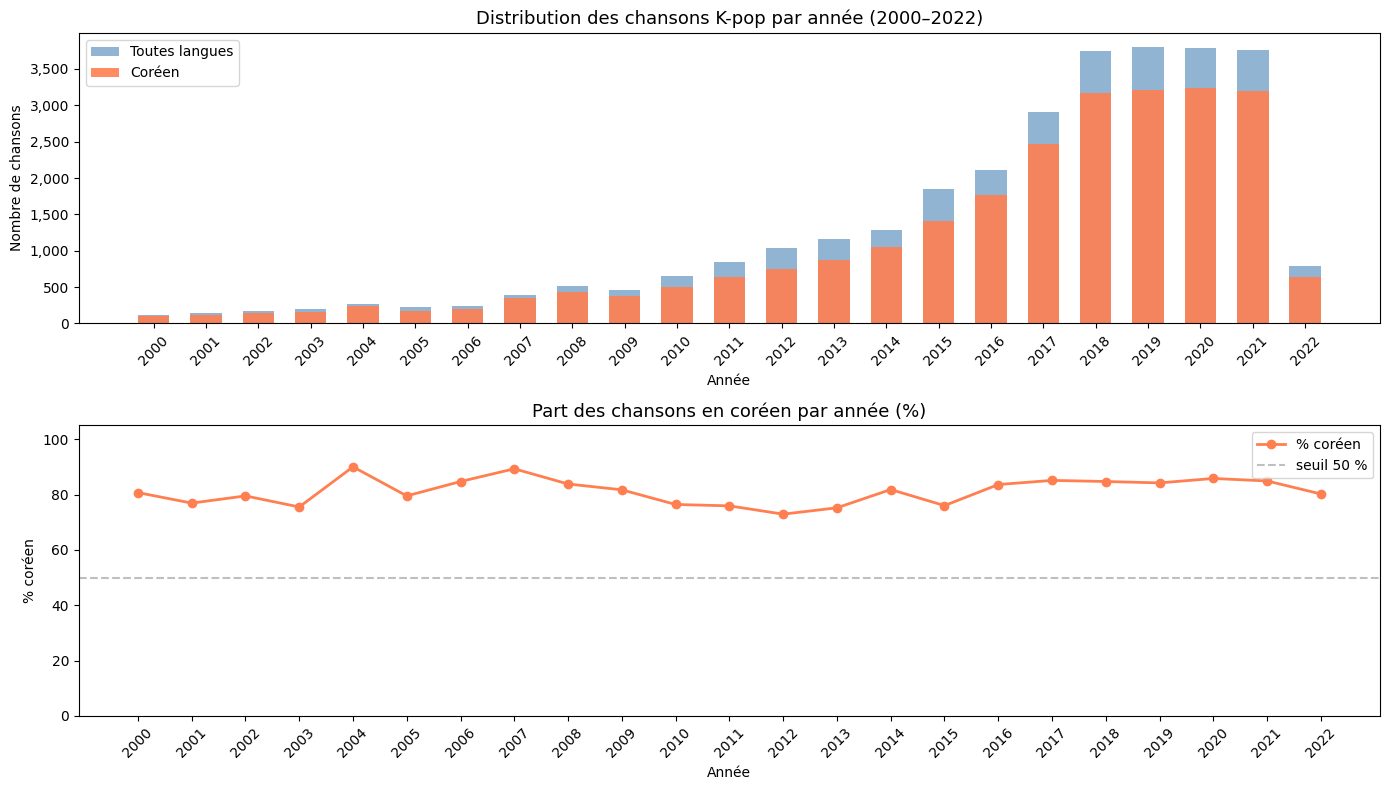


Résumé par année :
      total  coréen  % coréen
year                         
2000    119      96      80.7
2001    147     113      76.9
2002    176     140      79.5
2003    204     154      75.5
2004    271     244      90.0
2005    220     175      79.5
2006    235     199      84.7
2007    384     343      89.3
2008    513     430      83.8
2009    454     371      81.7
2010    647     494      76.4
2011    849     644      75.9
2012   1032     752      72.9
2013   1161     873      75.2
2014   1289    1055      81.8
2015   1849    1406      76.0
2016   2111    1765      83.6
2017   2906    2473      85.1
2018   3745    3173      84.7
2019   3807    3207      84.2
2020   3783    3244      85.8
2021   3767    3198      84.9
2022    793     636      80.2


In [10]:
# Calcul des volumes et proportions par année
total_by_year  = df_kpop.groupby("year").size()
korean_by_year = df_kpop[df_kpop["is_korean"]].groupby("year").size()
korean_by_year = korean_by_year.reindex(total_by_year.index, fill_value=0)
pct_korean     = (korean_by_year / total_by_year * 100).round(1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# --- Graphique 1 : volumes absolus ---
x = total_by_year.index
ax1.bar(x, total_by_year,  0.6, label="Toutes langues", color="steelblue", alpha=0.6)
ax1.bar(x, korean_by_year, 0.6, label="Coréen",         color="coral",     alpha=0.9)
ax1.set_title(f"Distribution des chansons K-pop par année ({YEAR_MIN}–{YEAR_MAX})", fontsize=13)
ax1.set_ylabel("Nombre de chansons")
ax1.legend()
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# --- Graphique 2 : proportion de coréen ---
ax2.plot(x, pct_korean, color="coral", marker="o", linewidth=2, label="% coréen")
ax2.axhline(50, color="gray", linestyle="--", alpha=0.5, label="seuil 50 %")
ax2.set_title("Part des chansons en coréen par année (%)", fontsize=13)
ax2.set_ylabel("% coréen")
ax2.set_ylim(0, 105)
ax2.legend()

for ax in (ax1, ax2):
    ax.set_xlabel("Année")
    ax.set_xticks(x)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# --- Tableau récapitulatif ---
summary = pd.DataFrame({
    "total"    : total_by_year.astype(int),
    "coréen"   : korean_by_year.astype(int),
    "% coréen" : pct_korean,
})
print("\nRésumé par année :")
print(summary.to_string())

## 5. Nettoyage des paroles

Les paroles extraites de Genius contiennent des éléments qui ne font pas partie
du texte chanté et qui fausseraient les ratios calculés dans le notebook d'analyse :

| Élément parasite | Exemple | Supprimé par |
|---|---|---|
| Balises de structure | `[Chorus]`, `[Verse 1]` | regex `\[.*?\]` |
| Annotations Genius | `[이달의 소녀 "PTT" 가사]` | regex `\[.*?\]` |
| Didascalies | `(Produced by Kane Beatz)` | regex `\(.*?\)` |

On applique le nettoyage directement sur la colonne `lyrics` (pas de colonne intermédiaire),
puisque le texte brut ne sera plus utilisé après cet export.

In [11]:
def clean_lyrics(text: str) -> str:
    """Supprime les balises Genius et normalise les espaces."""
    text = str(text)
    text = re.sub(r'\[.*?\]', '', text)   # [Chorus], [가사]...
    text = re.sub(r'\(.*?\)', '', text)   # (Produced by...)
    text = re.sub(r'\n+', '\n', text).strip()
    return text

df_kpop["lyrics"] = df_kpop["lyrics"].apply(clean_lyrics)

# Vérification : on affiche un exemple avant/après
# (l'original n'est plus disponible après le nettoyage en place,
#  mais on vérifie que le texte restant est propre)
print("Exemple de paroles après nettoyage :")
print(df_kpop["lyrics"].iloc[10][:400])

# On s'assure qu'il ne reste pas de chansons avec des paroles vides après nettoyage
df_kpop["has_lyrics"] = (
    df_kpop["lyrics"].notna() &
    (df_kpop["lyrics"].astype(str).str.strip() != "") &
    (df_kpop["lyrics"].astype(str).str.len() > 50)
)
n = df_kpop["has_lyrics"].sum()
print(f"\nChansons avec paroles valides : {n:,} / {len(df_kpop):,} ({n/len(df_kpop)*100:.1f}%)")

Exemple de paroles après nettoyage :
Hit the closets. Here come the lyrical monsters
With weapons from neck up Wrecking flows with concepts
Burbs to projects, they yelling my name
Kero One, free us from mainstream shackles and chains
The messiah of indie music Be the movement
Do it yourself. Pursue it or else you'll lose it
Truth... I told myself as a young youth
Now I build with skills what haters try to undo
Edge of your seat flows

Chansons avec paroles valides : 30,460 / 30,462 (100.0%)


## 6. Export du dataset nettoyé

On exporte le dataset filtré et nettoyé au format CSV.
Ce fichier `kpop_dataset_clean.csv` est le point d'entrée du notebook d'analyse.

**Colonnes exportées :**

| Colonne | Description |
|---|---|
| `title` | Titre de la chanson |
| `artist` | Nom de l'artiste |
| `year` | Année de sortie |
| `lyrics` | Paroles nettoyées |
| `language_cld3` / `language_ft` / `language` | Langue détectée par chaque outil |
| `is_korean` | `True` si la chanson est détectée comme coréenne |
| `has_lyrics` | `True` si les paroles sont non-vides après nettoyage |

In [12]:
# Export CSV — encodage UTF-8 avec BOM pour compatibilité Excel
df_kpop.to_csv("kpop_dataset_clean.csv", index=False, encoding="utf-8-sig")

print(" Export terminé : kpop_dataset_clean.csv")
print(f"   {len(df_kpop):,} chansons · {df_kpop['artist'].nunique():,} artistes")
print(f"   Fenêtre : {YEAR_MIN}–{YEAR_MAX}")
print()
print("Ce fichier peut maintenant être chargé dans data_analysis_kpop_lyrics.ipynb.")

# Aperçu final du dataset
df_kpop.head(3)

 Export terminé : kpop_dataset_clean.csv
   30,462 chansons · 728 artistes
   Fenêtre : 2000–2022

Ce fichier peut maintenant être chargé dans data_analysis_kpop_lyrics.ipynb.


,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language,is_korean,has_lyrics
0,Eat You Up Remix,rap,BoA (),2011,589,"{""Flo Rida"",""BoA (보아)""}","Yeah\nOne time, it's your boy, DJ Montay, righ...",11023,en,en,en,False,True
1,Final Fantasy,rap,Tiger JK (JK),2011,544,"{""Roscoe Umali"",""Tiger JK (타이거JK)""}",So we representin' it\nCharter legend shit\nYo...,18258,en,en,en,False,True
2,Umalis Bar,rap,Tiger JK (JK),2000,437,"{""Roscoe Umali"",""Tiger JK (타이거JK)""}","""I'm perfected\nMy drunken style like Sam Seed...",18262,en,en,en,False,True
